<a href="https://colab.research.google.com/github/nithyasg05/A03-knn/blob/main/DS%203001%20-%20A03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Nithyasri Gopal

**Date:** 9/30/26

**Question 1 - Part 1**

Regression predicts a numeric outcome and classification predicts a category. With the example given in class from Environmental Protection Agency car data, regression would predict the baseline price (i.e. market price), and classification would predict the class (i.e. vehicle category).

**Question 1 - Part 2**

A confusion matrix counts predictions by actual class and predicted class. Rows are actual classes and columns are predictions. It helps us understand the proportions of true negatives, false negatives, true positives, and false positives present in the data. Diagonal cells count correct predictions and off-diagonal cells count misclassifications.

**Question 1 - Part 3**

SSE quantifies the total squared difference between the actual observed values and the values predicted by a model. It is a measure of the overall discrepancy between the model's predictions and true data. Lower SSE indicates that the model's predictions are closer to the actual values, whereas higher SSE indicates that the model's predictions are far off from the actual values.

**Question 1 - Part 4**

Overfitting is when a model learns the training data too well, capturing not only the underlying patterns but also the noise and random fluctuations specific to the training set. An overfit model will perform very well on the training data but poorly on unseen data because it has memorized the training examples.

Underfitting is when a model is too simple to capture the underlying patterns in the training data. An underfit model performs poorly on both the training data and test data because it hasn't learned the relationships between the features and target variable effectively.

**Question 1 - Part 5**

Splitting data into training and testng sets, and choosing k by evaluating accuracy or SSE on the test set, improves model performance primarily by preventing overfitting and ensuring the model's ability to generalize to new, unseen data. Additionally, you want to choose a k value that optimizes the model's performance on unseen data, so by testing different k values on the test set, you can identify the k that provides the best balance between bias and variance.

**Question 1 - Part 6**

With reporting a class label as a prediction, it is straightforward and tells you directly what the model believes the class is, allowing for easier understanding to arrive at a definitive decision. However, a single label also provides no insight into how confident the model is in its prediction (ex: it could be made with 99% certainty or 30% certainty, and the label doesn't convey that).

With reporting a probability distribution over class labels, it shows the model's confidence for each possible class, allowing the user to understand the likelihood of alternative outcomes. However, it can be complex to interpret a list of probabilities, especially for non-technical users, rather than a single, clear label.

**Question 2**

In [8]:
!git clone https://github.com/nithyasg05/A03-knn.git

fatal: destination path 'A03-knn' already exists and is not an empty directory.


In [10]:
!ls

A03-knn  sample_data


In [11]:
!cd A03-knn/

In [12]:
!ls

A03-knn  sample_data


In [14]:
!cd A03-knn/data/

**Question 2 - Part 1**

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_mines = pd.read_csv('./A03-knn/data/land_mines.csv')
print(df_mines.shape)
display(df_mines.head())

(338, 4)


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [16]:
print(df_mines.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None


In [17]:
print(df_mines['mine_type'].value_counts())

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


In [18]:
display(df_mines[['voltage', 'height', 'soil']].describe())

,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000


In [19]:
print(df_mines['soil'].value_counts())

soil
0.0    59
0.8    58
0.6    57
1.0    57
0.4    56
0.2    51
Name: count, dtype: int64


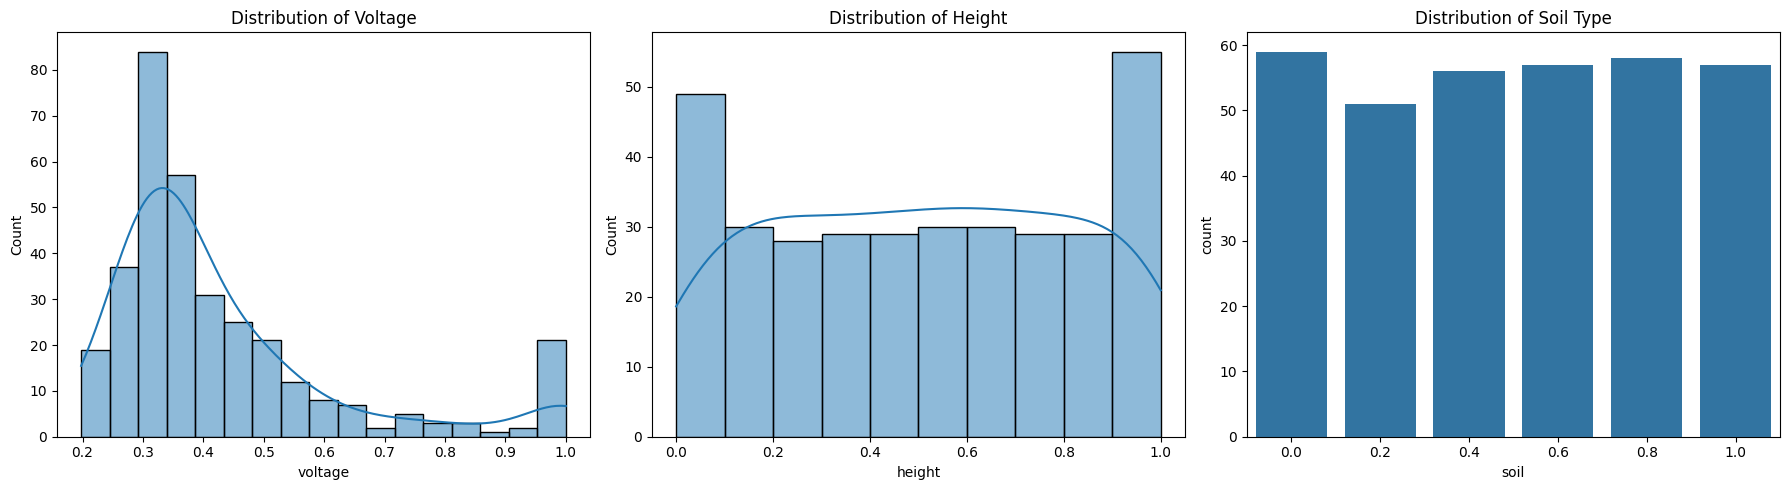

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_mines['voltage'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Voltage')

sns.histplot(df_mines['height'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Height')

sns.countplot(x=df_mines['soil'], ax=axes[2])
axes[2].set_title('Distribution of Soil Type')

plt.tight_layout()
plt.show()

EDA Summary:

The dataset contains 338 entries and 4 columns. All columns have non-null values, indicating no missing data. The mine_type column is the target variable and has 5 distinct classes (1-5). Voltage ranges from ~0.198-1, height ranges from 0-1, and soil ranges from 0-1. The soil feature has 6 distinct values (0.2, 0.4, 0.6, 0.8, 1.0), each appearing ~51-59 times.

**Question 2 - Part 2**

In [21]:
from sklearn.model_selection import train_test_split

X = df_mines[['voltage', 'height', 'soil']]
y = df_mines['mine_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of mine_type in y_train:")
print(y_train.value_counts(normalize=True))

print("\nDistribution of mine_type in y_test:")
print(y_test.value_counts(normalize=True))

X_train shape: (169, 3)
X_test shape: (169, 3)
y_train shape: (169,)
y_test shape: (169,)

Distribution of mine_type in y_train:
mine_type
1    0.207101
2    0.207101
3    0.195266
5    0.195266
4    0.195266
Name: proportion, dtype: float64

Distribution of mine_type in y_test:
mine_type
1    0.213018
2    0.207101
3    0.195266
4    0.195266
5    0.189349
Name: proportion, dtype: float64


**Question 2 - Part 3**

Accuracies for k from 1 to 20: [0.40236686390532544, 0.4378698224852071, 0.378698224852071, 0.35502958579881655, 0.3136094674556213, 0.3254437869822485, 0.3136094674556213, 0.3136094674556213, 0.34911242603550297, 0.33727810650887574, 0.35502958579881655, 0.33727810650887574, 0.34911242603550297, 0.3136094674556213, 0.33136094674556216, 0.3431952662721893, 0.3609467455621302, 0.33727810650887574, 0.33727810650887574, 0.3431952662721893]
Optimal k: 2 with accuracy: 0.4379


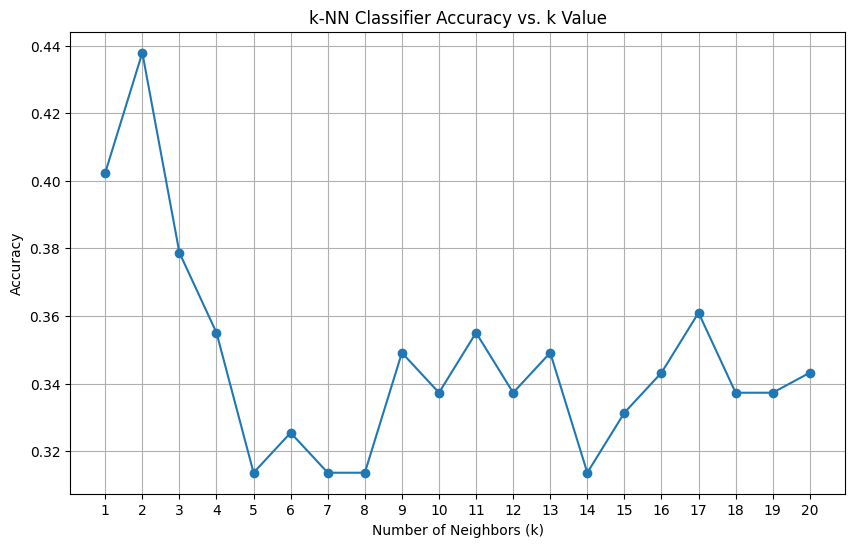

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

accuracies = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = metrics.accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

optimal_k = accuracies.index(max(accuracies)) + 1
print(f"Accuracies for k from 1 to 20: {accuracies}")
print(f"Optimal k: {optimal_k} with accuracy: {max(accuracies):.4f}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), accuracies, marker='o')
plt.title('k-NN Classifier Accuracy vs. k Value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

Explanation:

The value for 'k' was selected by evaluating the kNN classifer's performance across a range of possible k values. I iterated through k from 1-20, and for each value, a kNN model was trained on the training data and accuracy was measured on the test set. The k value that resulted in the highest accuracy on the test set (0.4379) was k=2.

**Question 2 - Part 4**

In [23]:
from sklearn.metrics import confusion_matrix, classification_report

knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train, y_train)
y_pred_optimal = knn_optimal.predict(X_test)

print("Confusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_optimal)))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimal))

Confusion Matrix:


,0,1,2,3,4
0,25,0,6,4,1
1,0,32,0,3,0
2,12,2,9,6,4
3,12,5,8,8,0
4,15,2,10,5,0



Classification Report:
              precision    recall  f1-score   support

           1       0.39      0.69      0.50        36
           2       0.78      0.91      0.84        35
           3       0.27      0.27      0.27        33
           4       0.31      0.24      0.27        33
           5       0.00      0.00      0.00        32

    accuracy                           0.44       169
   macro avg       0.35      0.42      0.38       169
weighted avg       0.36      0.44      0.39       169



Explanation:

The model achieved an overall accuracy of 44% on the test set, which is consistent with the optimal accuracy found during the k selection process. The model is most accurate at identifying Mine Type 2. Out of 35 actual Mine Type 2 instances, 32 were correctly classified. For Mine Type 1, 25 out of 36 instances were correctly identified, however 6 were misclassifications, resulting in lower precision. Finally, the model struggles significantly with Mine Type 5. Out of 32 instances, none were correctly predicted, resulting in a complete failure to identify this class.

So, the 44% overall accuracy is an average that hides significant variations in performance, as the model does not perform the similarly across several mine types.

**Question 2 - Part 5**

Here is how I would advise someone to use this predictive model in practice:

1.  **Prioritize Mine Type 2:** The model is relatively good at identifying Mine Type 2 (high precision and recall). If the model predicts Mine Type 2, there is a higher confidence that it is indeed a Mine Type 2, allowing for more targeted and efficient procedures specific to that type.

2.  **Exercise Extreme Caution for Mine Type 5 (and 3, 4):** The model completely fails to identify Mine Type 5 and performs poorly on Mine Types 3 and 4. Therefore, any prediction for these types, or a prediction that is *not* Mine Type 2, should be treated with the highest level of caution.

3.  **Use as a Screening Tool, Not a Definitive Identifier:** The model can serve as an initial screening tool to flag potential mine types. However, it should never replace thorough, on-the-ground verification by trained personnel.

4.  **Continuous Improvement:** The model's current accuracy is relatively low (44%). It should be seen as a starting point. Further data collection, feature engineering (e.g., incorporating more sensor data), and experimenting with more sophisticated models are crucial for improving its reliability before widespread deployment.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 1b8e561

- **AI tool and model used:** Gemini 2.5 Flash

### *Prompts used

1. Go through this notebook and find any mistakes. Then, identify any proper revisions.
2. Explain why the description in Question 2 - Part 4 should be changed.

### *AI-proposed changes


1.  **Confusion Matrix Labels:** The `pd.DataFrame` display for the confusion matrix was updated to explicitly label rows and columns with the actual `mine_type` values (1-5). This prevents misinterpretation of default integer indices and clearly shows which row/column corresponds to which mine type.
2.  **Q2-P4 Explanation Revision:** The explanation for Question 2 - Part 4 was revised to clarify the interpretation of precision and recall for 'Mine Type 1'. Specifically, it now emphasizes that while the model had decent recall for Type 1, its low precision indicates many instances predicted as Type 1 were actually other mine types. This provides a more accurate and consistent narrative with the classification report.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept| This is a valid change because it is important to clearly label rows and columns in the confusion matrix to make it easier for all users to understand. |
| 2 | Accept| This is a valid change because it is important to determine why Mine Type 1 may have some advantages and disadvantages. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

**Question 1 - Part 1**

Regression predicts a numeric outcome and classification predicts a category. With the example given in class from Environmental Protection Agency car data, regression would predict the baseline price (i.e. market price), and classification would predict the class (i.e. vehicle category).

**Question 1 - Part 2**

A confusion matrix counts predictions by actual class and predicted class. Rows are actual classes and columns are predictions. It helps us understand the proportions of true negatives, false negatives, true positives, and false positives present in the data. Diagonal cells count correct predictions and off-diagonal cells count misclassifications.

**Question 1 - Part 3**

SSE quantifies the total squared difference between the actual observed values and the values predicted by a model. It is a measure of the overall discrepancy between the model's predictions and true data. Lower SSE indicates that the model's predictions are closer to the actual values, whereas higher SSE indicates that the model's predictions are far off from the actual values.

**Question 1 - Part 4**

Overfitting is when a model learns the training data too well, capturing not only the underlying patterns but also the noise and random fluctuations specific to the training set. An overfit model will perform very well on the training data but poorly on unseen data because it has memorized the training examples.

Underfitting is when a model is too simple to capture the underlying patterns in the training data. An underfit model performs poorly on both the training data and test data because it hasn't learned the relationships between the features and target variable effectively.

**Question 1 - Part 5**

Splitting data into training and testng sets, and choosing k by evaluating accuracy or SSE on the test set, improves model performance primarily by preventing overfitting and ensuring the model's ability to generalize to new, unseen data. Additionally, you want to choose a k value that optimizes the model's performance on unseen data, so by testing different k values on the test set, you can identify the k that provides the best balance between bias and variance.

**Question 1 - Part 6**

With reporting a class label as a prediction, it is straightforward and tells you directly what the model believes the class is, allowing for easier understanding to arrive at a definitive decision. However, a single label also provides no insight into how confident the model is in its prediction (ex: it could be made with 99% certainty or 30% certainty, and the label doesn't convey that).

With reporting a probability distribution over class labels, it shows the model's confidence for each possible class, allowing the user to understand the likelihood of alternative outcomes. However, it can be complex to interpret a list of probabilities, especially for non-technical users, rather than a single, clear label.

**Question 2**

In [1]:
!git clone https://github.com/nithyasg05/A03-knn.git

Cloning into 'A03-knn'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 25 (delta 2), reused 1 (delta 1), pack-reused 21 (from 1)
Receiving objects: 100% (25/25), 110.88 KiB | 3.17 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [2]:
!ls

A03-knn  sample_data


In [3]:
!cd A03-knn/

In [4]:
!ls

A03-knn  sample_data


In [5]:
!cd A03-knn/data/

**Question 2 - Part 1**

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_mines = pd.read_csv('./A03-knn/data/land_mines.csv')
print(df_mines.shape)
display(df_mines.head())

(338, 4)


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [7]:
print(df_mines.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None


In [8]:
print(df_mines['mine_type'].value_counts())

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


In [9]:
display(df_mines[['voltage', 'height', 'soil']].describe())

,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000


In [10]:
print(df_mines['soil'].value_counts())

soil
0.0    59
0.8    58
0.6    57
1.0    57
0.4    56
0.2    51
Name: count, dtype: int64


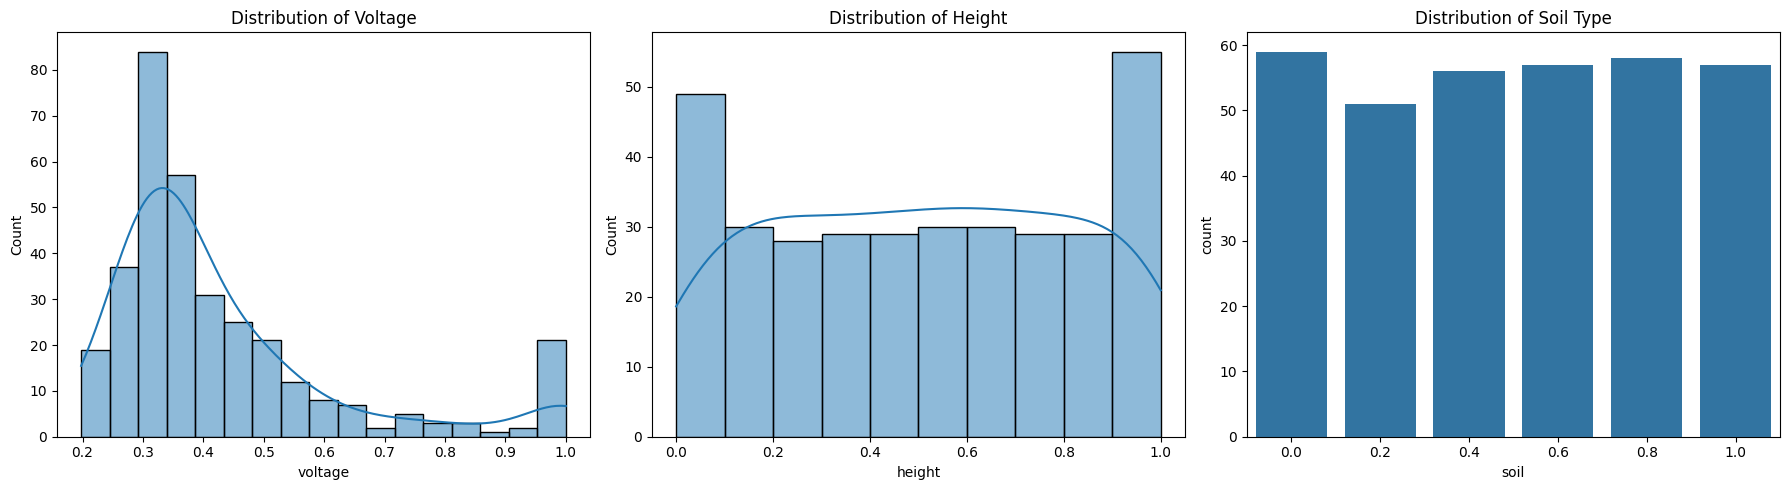

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_mines['voltage'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Voltage')

sns.histplot(df_mines['height'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Height')

sns.countplot(x=df_mines['soil'], ax=axes[2])
axes[2].set_title('Distribution of Soil Type')

plt.tight_layout()
plt.show()

EDA Summary:

The dataset contains 338 entries and 4 columns. All columns have non-null values, indicating no missing data. The mine_type column is the target variable and has 5 distinct classes (1-5). Voltage ranges from ~0.198-1, height ranges from 0-1, and soil ranges from 0-1. The soil feature has 6 distinct values (0.2, 0.4, 0.6, 0.8, 1.0), each appearing ~51-59 times.

**Question 2 - Part 2**

In [12]:
from sklearn.model_selection import train_test_split

X = df_mines[['voltage', 'height', 'soil']]
y = df_mines['mine_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of mine_type in y_train:")
print(y_train.value_counts(normalize=True))

print("\nDistribution of mine_type in y_test:")
print(y_test.value_counts(normalize=True))

X_train shape: (169, 3)
X_test shape: (169, 3)
y_train shape: (169,)
y_test shape: (169,)

Distribution of mine_type in y_train:
mine_type
1    0.207101
2    0.207101
3    0.195266
5    0.195266
4    0.195266
Name: proportion, dtype: float64

Distribution of mine_type in y_test:
mine_type
1    0.213018
2    0.207101
3    0.195266
4    0.195266
5    0.189349
Name: proportion, dtype: float64


**Question 2 - Part 3**

Accuracies for k from 1 to 20: [0.40236686390532544, 0.4378698224852071, 0.378698224852071, 0.35502958579881655, 0.3136094674556213, 0.3254437869822485, 0.3136094674556213, 0.3136094674556213, 0.34911242603550297, 0.33727810650887574, 0.35502958579881655, 0.33727810650887574, 0.34911242603550297, 0.3136094674556213, 0.33136094674556216, 0.3431952662721893, 0.3609467455621302, 0.33727810650887574, 0.33727810650887574, 0.3431952662721893]
Optimal k: 2 with accuracy: 0.4379


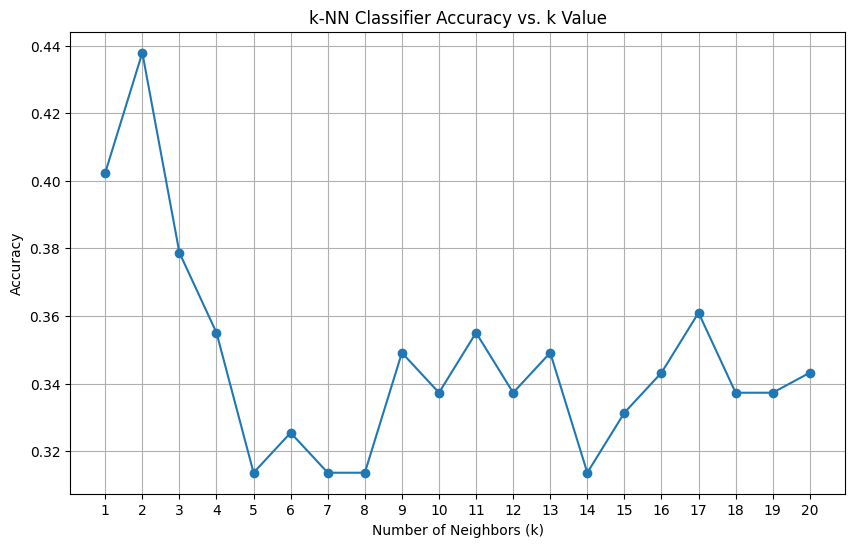

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

accuracies = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = metrics.accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

optimal_k = accuracies.index(max(accuracies)) + 1
print(f"Accuracies for k from 1 to 20: {accuracies}")
print(f"Optimal k: {optimal_k} with accuracy: {max(accuracies):.4f}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), accuracies, marker='o')
plt.title('k-NN Classifier Accuracy vs. k Value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

Explanation:

The value for 'k' was selected by evaluating the kNN classifer's performance across a range of possible k values. I iterated through k from 1-20, and for each value, a kNN model was trained on the training data and accuracy was measured on the test set. The k value that resulted in the highest accuracy on the test set (0.4379) was k=2.

**Question 2 - Part 4**

In [14]:
from sklearn.metrics import confusion_matrix, classification_report

knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train, y_train)
y_pred_optimal = knn_optimal.predict(X_test)

print("Confusion Matrix:")
# Add labels to the confusion matrix for better readability
display(pd.DataFrame(confusion_matrix(y_test, y_pred_optimal), index=np.unique(y_test), columns=np.unique(y_test)))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimal))

Confusion Matrix:


,1,2,3,4,5
1,25,0,6,4,1
2,0,32,0,3,0
3,12,2,9,6,4
4,12,5,8,8,0
5,15,2,10,5,0



Classification Report:
              precision    recall  f1-score   support

           1       0.39      0.69      0.50        36
           2       0.78      0.91      0.84        35
           3       0.27      0.27      0.27        33
           4       0.31      0.24      0.27        33
           5       0.00      0.00      0.00        32

    accuracy                           0.44       169
   macro avg       0.35      0.42      0.38       169
weighted avg       0.36      0.44      0.39       169



Explanation:

The model achieved an overall accuracy of 44% on the test set, which is consistent with the optimal accuracy found during the k selection process. The model is most accurate at identifying Mine Type 2, with a high precision (0.78) and recall (0.91), meaning it correctly identifies most of the actual Mine Type 2s and most of its predictions for Type 2 are accurate. Out of 35 actual Mine Type 2 instances, 32 were correctly classified.

For Mine Type 1, while 25 out of 36 actual instances were correctly identified (recall of 0.69), its precision is quite low (0.39). This indicates that a significant number of instances predicted by the model as Mine Type 1 were actually other mine types. So, while it catches a good portion of actual Type 1 mines, it also makes many false positive predictions for Type 1.

Finally, the model struggles significantly with Mine Type 5. Out of 32 instances, none were correctly predicted, resulting in a complete failure to identify this class (precision, recall, and f1-score are 0.00).

So, the 44% overall accuracy is an average that hides significant variations in performance, as the model does not perform similarly across several mine types.

**Question 2 - Part 5**

Given the model's performance, particularly its uneven accuracy across different mine types, here's how I would advise someone to use this predictive model in practice, especially in a sensitive context like mine removal:

1.  **Prioritize Mine Type 2:** The model is relatively good at identifying Mine Type 2 (high precision and recall). If the model predicts Mine Type 2, there is a higher confidence that it is indeed a Mine Type 2, allowing for more targeted and efficient procedures specific to that type.

2.  **Exercise Extreme Caution for Mine Type 5 (and 3, 4):** The model completely fails to identify Mine Type 5 and performs poorly on Mine Types 3 and 4. Therefore, any prediction for these types, or a prediction that is *not* Mine Type 2, should be treated with the highest level of caution. It should not be used as a primary indicator for clearing operations for these types. Instead, these areas should default to the most conservative and safest mine removal protocols, assuming the worst-case scenario (e.g., highly unstable or dangerous mine types).

3.  **Use as a Screening Tool, Not a Definitive Identifier:** The model can serve as an initial screening tool to flag potential mine types. However, it should never replace thorough, on-the-ground verification by trained personnel. Its primary utility would be to help prioritize where to send expert teams and what initial precautions to take.

4.  **Focus on False Negatives:** For a humanitarian aid agency, false negatives (failing to detect a mine) are far more critical than false positives (incorrectly identifying something as a mine). While the confusion matrix doesn't directly show false negatives *per se* for specific types, the low recall for types 3, 4, and 5 indicates a high risk of missing these mines. The advice should be to minimize the risk of missing any mine, even if it means a higher rate of false alarms or slower clearance rates.

5.  **Continuous Improvement:** The model's current accuracy is relatively low (44%). It should be seen as a starting point. Further data collection, feature engineering (e.g., incorporating more sensor data), and experimenting with more sophisticated models or ensemble methods are crucial for improving its reliability before widespread deployment. Regular re-evaluation of the model's performance on new data is essential.

In summary, the model provides some valuable insights, particularly for Mine Type 2, but its overall limitations, especially for other types, necessitate a highly cautious, human-supervised approach where safety protocols always trump model predictions when there's ambiguity or poor performance.

### *Reflection on AI assistance

The AI assistance significantly improved the clarity of the model's performance analysis by enhancing confusion matrix readability with explicit labels and refining the Q2-P4 explanation for 'Mine Type 1' to more accurately reflect its nuanced precision and recall. However, a notable limitation of the AI was it needing explicit prompts to identify these necessary revisions rather than proactively suggesting them. Verification of these changes involved reviewing the updated confusion matrix output for clear labeling and the revised explanation for accuracy and consistency with the classification report. Despite these improvements in documentation and explanation, a primary concern remains the model's low overall accuracy (44%) and its complete failure to predict Mine Type 5, indicating it is currently unsuitable for more sensitive applications without further development and validation.